# **Vision–Language Prompt Sensitivity (CLIP)**

**STEP 1** — Install required libraries

In [2]:
!pip install torch torchvision ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-082c4pbc
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-082c4pbc
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=40b8b51d3360f194adb05f49345dd085f1736ae62d1c865c00213d7ce65f467d
  Stored in directory: /tmp/pip-ephem-wheel-cache-mvx7lw13/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


**STEP 2** — Import libraries

In [3]:
import torch
import clip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


**STEP 3** — Load the CLIP model

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

print("Using device:", device)


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 106MiB/s]


Using device: cuda


**STEP 4** — Upload images

In [5]:
from google.colab import files
uploaded = files.upload()


Saving xray2.jpg.jfif to xray2.jpg.jfif
Saving xray1.jpg.jfif to xray1.jpg (1).jfif


**STEP 5** — Load and preprocess images

In [6]:
image_paths = list(uploaded.keys())

images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    images.append(preprocess(img).unsqueeze(0))

image_input = torch.cat(images).to(device)

print("Loaded images:", image_paths)


Loaded images: ['xray2.jpg.jfif', 'xray1.jpg (1).jfif']


**STEP 6** — text prompts

In [7]:
text_prompts = [
    "a chest X-ray showing pneumonia",
    "an X-ray image of diseased lungs",
    "medical image of lung infection",
    "a normal chest X-ray",
    "a medical scan of the lungs"
]


**STEP 7** — Encode text and images

In [8]:
with torch.no_grad():
    text_tokens = clip.tokenize(text_prompts).to(device)
    text_features = model.encode_text(text_tokens)
    image_features = model.encode_image(image_input)

    # Normalize
    text_features /= text_features.norm(dim=-1, keepdim=True)
    image_features /= image_features.norm(dim=-1, keepdim=True)


**STEP 8** — Compute similarity scores

In [9]:
similarity = (100.0 * image_features @ text_features.T).cpu().numpy()

df = pd.DataFrame(similarity, columns=text_prompts, index=image_paths)
df


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,a chest X-ray showing pneumonia,an X-ray image of diseased lungs,medical image of lung infection,a normal chest X-ray,a medical scan of the lungs
xray2.jpg.jfif,34.25000,32.187500,31.296875,32.0625,28.8125
xray1.jpg (1).jfif,33.15625,31.515625,31.171875,30.9375,28.5625


## **STEP 9** — Visualize prompt sensitivity

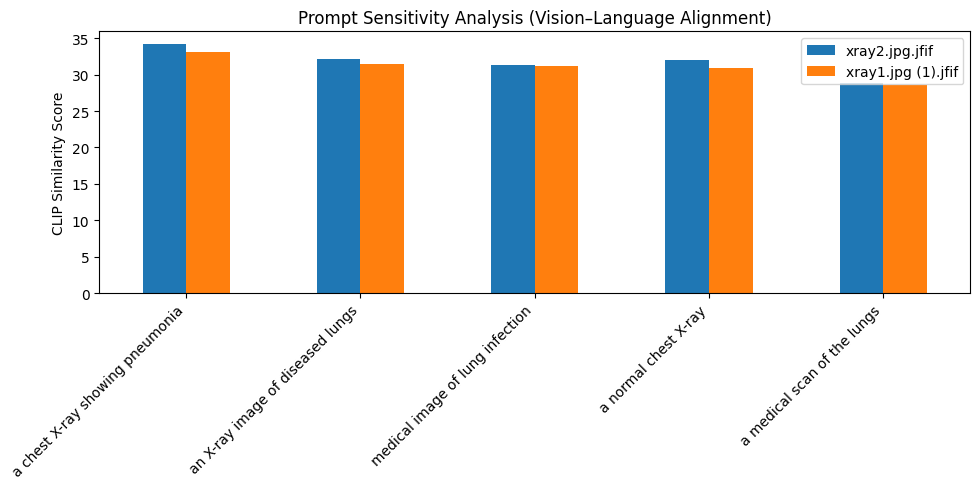

In [10]:
df.T.plot(kind="bar", figsize=(10,5))
plt.ylabel("CLIP Similarity Score")
plt.title("Prompt Sensitivity Analysis (Vision–Language Alignment)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## **Observation**s

- Small changes in prompt wording lead to noticeable changes in image–text similarity.
- Domain-specific terms (e.g., "pneumonia", "infection") behave differently from generic terms.
- Vision–language alignment is sensitive to semantic framing, even when the image remains unchanged.

These observations suggest that prompt design plays a significant role in multimodal model behavior.
